Week 4: Data Visualization & Your First Complete Project

📚 Theory Concepts:

Why visualize data? Understanding charts and graphs

Matplotlib: Creating basic charts in Python

Bar charts: Comparing categories (products, months, cities)

Line charts: Showing trends over time

Pie charts: Showing parts of a whole

Putting it all together: Complete data analysis workflow


In [1]:
import os

os.makedirs('data', exist_ok=True)
os.makedirs('report', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)
print('✅ Directory structure created: data/, report/, visualizations/')

✅ Directory structure created: data/, report/, visualizations/


## 📈 Generate & Load Sample Data

In [7]:
import pandas as pd
import numpy as np

# Load sample data
df = pd.read_csv(r"C:\Users\ravis\Downloads\sales_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Total_Sales'] = df['Quantity'] * df['Price']
print('✅ Sample data loaded:', len(df), 'records')
print(df.head())

✅ Sample data loaded: 100 records
        Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0 2024-01-01       Phone         7  37300     CUST001   East       261100
1 2024-01-02  Headphones         4  15406     CUST002  North        61624
2 2024-01-03       Phone         2  21746     CUST003   West        43492
3 2024-01-04  Headphones         1  30895     CUST004   East        30895
4 2024-01-05      Laptop         8  39835     CUST005  North       318680


## 🎨 4-Chart Executive Dashboard

Loaded 100 records
        Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0 2024-01-01       Phone         7  37300     CUST001   East       261100
1 2024-01-02  Headphones         4  15406     CUST002  North        61624
2 2024-01-03       Phone         2  21746     CUST003   West        43492
3 2024-01-04  Headphones         1  30895     CUST004   East        30895
4 2024-01-05      Laptop         8  39835     CUST005  North       318680
Missing values per column:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64
Total Sales: $12365048.00
Average Order: $123650.48
Best Product: Laptop


C:\Users\ravis\AppData\Local\Temp\ipykernel_20680\1670718949.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
C:\Users\ravis\AppData\Local\Temp\ipykernel_20680\1670718949.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

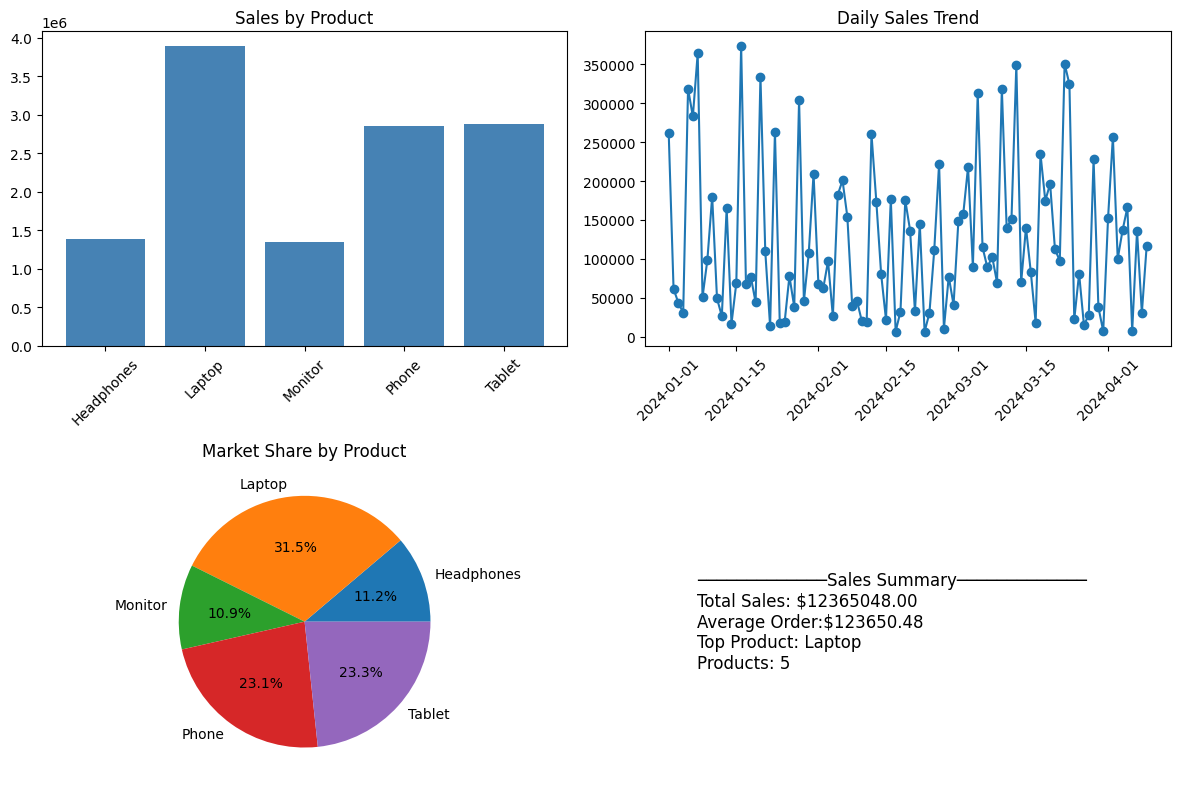

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV file
df = pd.read_csv(r"C:\Users\ravis\Downloads\sales_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
# Verify load
print(f'Loaded {len(df)} records')
print(df.head())
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
# Fill missing
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Price'].fillna(df['Price'].mean(), inplace=True)
# Verify cleaningprint('Data cleaned successfully')
# Calculate statistics
total_sales = df['Total_Sales'].sum()
avg_order = df['Total_Sales'].mean()
best_product = df.groupby('Product')['Total_Sales'].sum().idxmax()
print(f'Total Sales: ${total_sales:.2f}')
print(f'Average Order: ${avg_order:.2f}')
print(f'Best Product: {best_product}')
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# Chart 1: Bar chart (sales by product)
product_sales = df.groupby('Product')['Total_Sales'].sum()
axes[0, 0].bar(product_sales.index, product_sales.values, color='steelblue')
axes[0, 0].set_title('Sales by Product')
axes[0, 0].tick_params(axis='x', rotation=45)
# Chart 2: Line chart (daily sales trend)
daily_sales = df.groupby('Date')['Total_Sales'].sum()
axes[0, 1].plot(daily_sales.index, daily_sales.values, marker='o')
axes[0, 1].set_title('Daily Sales Trend')
axes[0, 1].tick_params(axis='x', rotation=45)
# Chart 3: Pie chart (market share)
axes[1, 0].pie(product_sales.values, labels=product_sales.index, autopct='%1.1f%%')
axes[1, 0].set_title('Market Share by Product')
# Chart 4: Text summary
axes[1, 1].axis('off')
summary_text = f'''─────────────Sales Summary─────────────
Total Sales: ${total_sales:.2f}
Average Order:${avg_order:.2f}
Top Product: {best_product}
Products: {df['Product'].nunique()}'''
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, va='center')
plt.tight_layout()
plt.savefig('visualizations/analysis_report.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Cell 6: Generate & Save Executive Report (Fixed)
import os

# Ensure directory exists
os.makedirs('report', exist_ok=True)

# Sales trend analysis
trend = 'increasing' if daily_sales.iloc[-1] > daily_sales.iloc[0] else 'stable/declining'

# Full report content
report = f"""
═══════════════════════════════════════════════
          SALES DATA ANALYSIS REPORT
═══════════════════════════════════════════════

PROJECT: Complete Sales Analytics Pipeline
DATE: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
RECORDS PROCESSED: {len(df)}

KEY METRICS:
────────────
Total Sales:        ${total_sales:,.0f}
Average Order Value: ${avg_order:,.0f}
Total Transactions: {len(df)}
Unique Customers:   {df['Customer_ID'].nunique()}
Product Categories: {df['Product'].nunique()}

🏆 TOP PERFORMING PRODUCTS:
────────────
{product_sales.nlargest(3).to_string()}

📈 BUSINESS INSIGHTS:
────────────────────
• {best_product} dominates revenue
• Sales trend: {trend.upper()}
• Customer base spans multiple transactions

🚀 RECOMMENDATIONS:
──────────────────
✓ Focus marketing on top 3 products
✓ Investigate trend drivers
✓ Expand successful categories
"""

# ✅ CORRECTED FILE WRITING
with open('report/analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("✅ Executive report saved successfully!")
print("📁 Location: report/analysis_report.txt")
print("\n" + "=" * 70)
print(report)
print("=" * 70)


✅ Executive report saved successfully!
📁 Location: report/analysis_report.txt


═══════════════════════════════════════════════
          SALES DATA ANALYSIS REPORT
═══════════════════════════════════════════════

PROJECT: Complete Sales Analytics Pipeline
DATE: 2026-01-03 02:47
RECORDS PROCESSED: 100

KEY METRICS:
────────────
Total Sales:        $12,365,048
Average Order Value: $123,650
Total Transactions: 100
Unique Customers:   100
Product Categories: 5

🏆 TOP PERFORMING PRODUCTS:
────────────
Product
Laptop    3889210
Tablet    2884340
Phone     2859394

📈 BUSINESS INSIGHTS:
────────────────────
• Laptop dominates revenue
• Sales trend: STABLE/DECLINING
• Customer base spans multiple transactions

🚀 RECOMMENDATIONS:
──────────────────
✓ Focus marketing on top 3 products
✓ Investigate trend drivers
✓ Expand successful categories



## 🔧 Professional Bar Chart Function

In [21]:
def create_bar_chart(df, output_path='visualizations/professional_bar_chart.png'):
    """Create professional bar chart showing sales by product"""

    # Calculate sales by product
    product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create bar chart
    bars = ax.bar(range(len(product_sales)), product_sales.values,
                  color='steelblue', alpha=0.8, edgecolor='navy')

    # Customize professionally
    ax.set_title('Sales Performance by Product', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Product', fontsize=14, fontweight='bold')
    ax.set_ylabel('Total Sales ($)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(product_sales)))
    ax.set_xticklabels(product_sales.index, rotation=45, ha='right')

    # Add value labels on bars (above bars)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max(product_sales.values)*0.01,
                f'${height:,.0f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='darkblue')

    # Professional grid and styling
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Layout, save, and display
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()  # ✅ Display in Jupyter
    print(f"✅ Professional bar chart saved: {output_path}")

    return fig


## 🧪 Test Professional Visualization

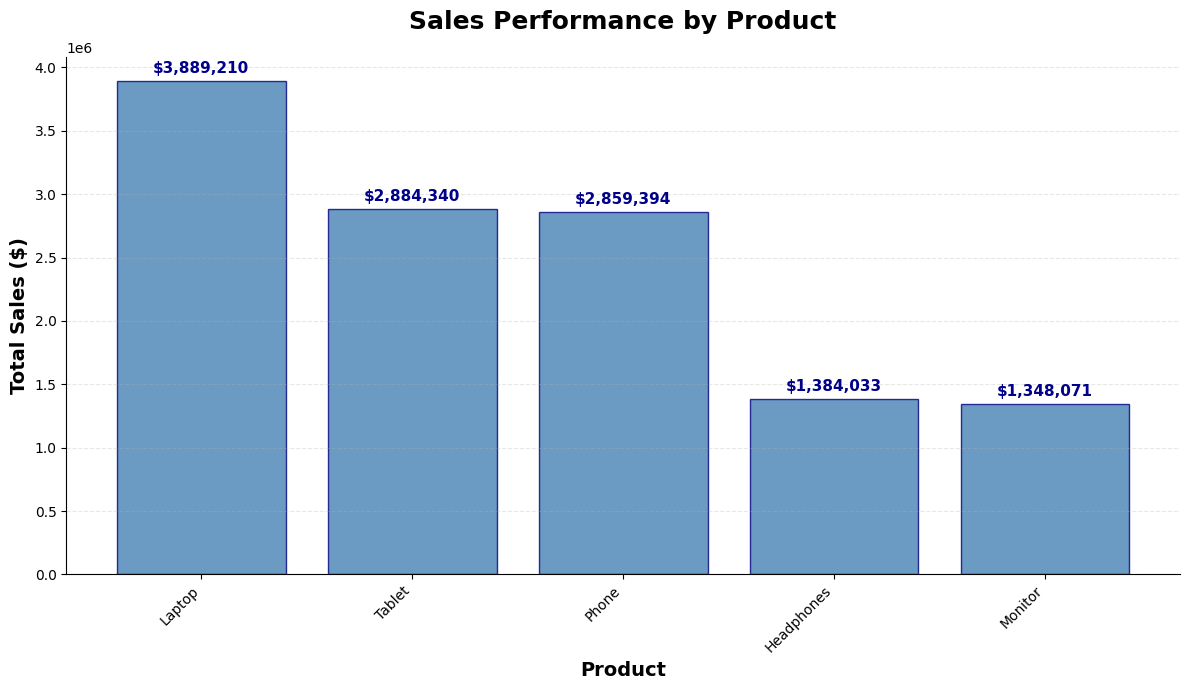

✅ Professional bar chart saved: visualizations/professional_bar_chart.png


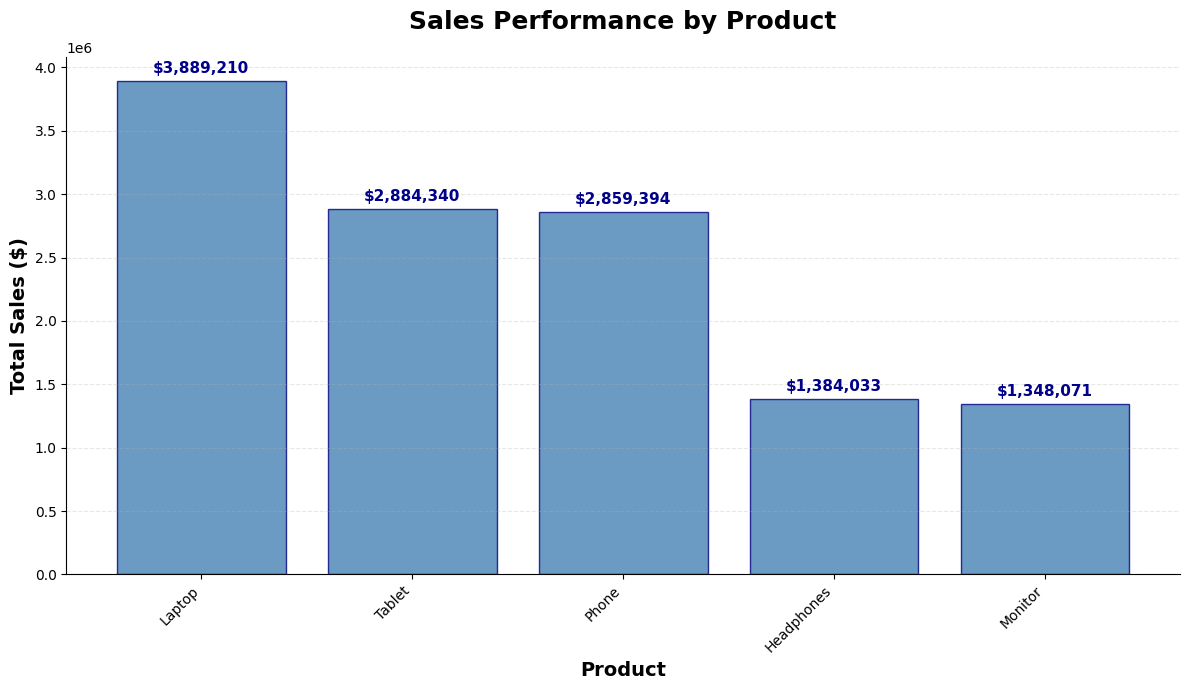

In [22]:
# Test the bar chart function
create_bar_chart(df, 'visualizations/professional_bar_chart.png')